# Setup

In [ ]:
import os
import logging
import warnings
import numpy as np
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


logging.getLogger("tensorflow").setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
EPOCHS       = 100
BATCH_SIZE   = 64
PATIENCE_ES  = 10
PATIENCE_REDUCELR_ON_PLATEAU = 5

MODEL_PATH   = "best_model.keras"
TFLITE_PATH  = "model_simple_int8.tflite"
MONITOR_MET  = "val_accuracy"
LR = 0.01

IMG_SIZE = (28, 28)
INPUT_SHAPE = (*IMG_SIZE, 1)

AUTOTUNE = tf.data.AUTOTUNE

# Dataset

In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])

def get_datasets():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    x_train = np.expand_dims(x_train, axis=-1)
    x_test = np.expand_dims(x_test, axis=-1)
    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test = tf.keras.utils.to_categorical(y_test, 10)

    indices = np.arange(len(x_train))
    np.random.shuffle(indices)
    x_train = x_train[indices]
    y_train = y_train[indices]

    val_size = int(len(x_train) * 0.1)
    x_val, y_val = x_train[:val_size], y_train[:val_size]
    x_train, y_train = x_train[val_size:], y_train[val_size:]

    train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(BATCH_SIZE)
    val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE)
    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(BATCH_SIZE)

    return train_ds, val_ds, test_ds

def preprocess(image, label):
    return tf.cast(image, tf.float32) / 255.0, label

def prepare_dataset(ds, is_training=False):
    ds = ds.cache()
    if is_training:
        ds = ds.shuffle(buffer_size=1000)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

raw_train_ds, raw_val_ds, raw_test_ds = get_datasets()
CLASS_NAMES = [str(i) for i in range(10)]

train_ds = prepare_dataset(raw_train_ds, is_training=True)
val_ds = prepare_dataset(raw_val_ds)
test_ds = prepare_dataset(raw_test_ds)

I0000 00:00:1771080539.455528      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


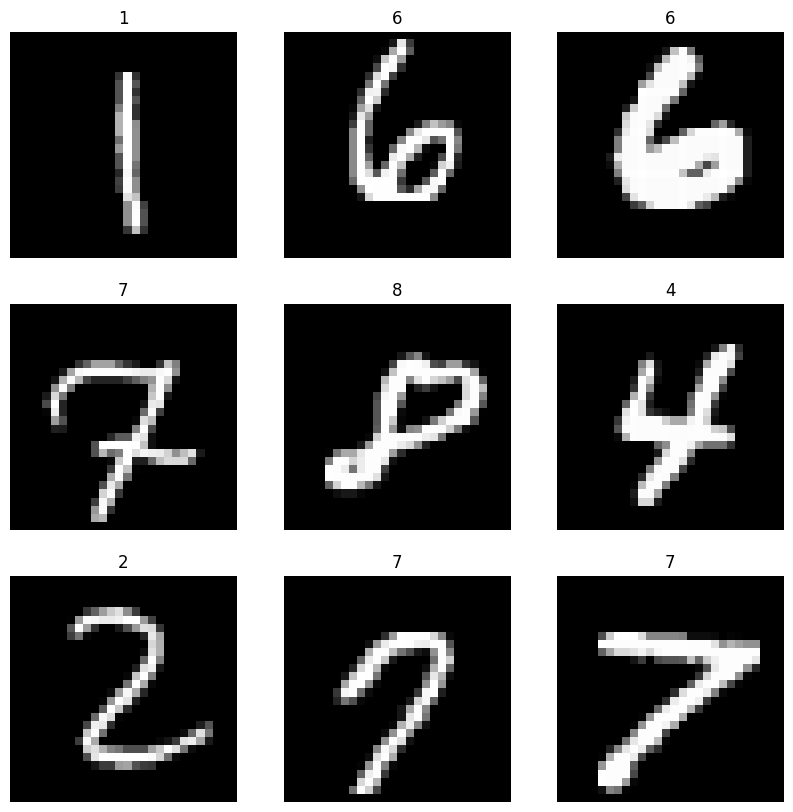

In [4]:
def plot_samples(dataset, class_names, num_samples=9):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):
        for i in range(num_samples):
            ax = plt.subplot(3, 3, i + 1)
            img_array = images[i].numpy().astype("uint8").squeeze()
            label_index = np.argmax(labels[i])
            plt.imshow(img_array, cmap='gray')
            plt.title(class_names[label_index])
            plt.axis("off")
    plt.show()

plot_samples(raw_train_ds, CLASS_NAMES)

# Helpers

In [5]:
# -------------------------------------------------------------------
# 2) Helpers
# -------------------------------------------------------------------
def get_callbacks():
    return [
        EarlyStopping(monitor=MONITOR_MET, patience=PATIENCE_ES, verbose=0, restore_best_weights=True),
        ModelCheckpoint(MODEL_PATH,   monitor=MONITOR_MET, save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor=MONITOR_MET, factor=0.1, patience=PATIENCE_REDUCELR_ON_PLATEAU, min_lr=1e-6, verbose=1)
    ]

def plot_history(history):
    plt.figure(figsize=(12,4))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

def evaluate_model(model, test_data, y_test=None):
    loss, acc = model.evaluate(test_data, verbose=0)
    print(f"Acurácia final no test set: {acc:.4f}")
    return loss, acc

# Model

In [6]:
def create_balanced_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=INPUT_SHAPE),
        tf.keras.layers.Conv2D(12, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(12, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Conv2D(24, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
    ], name="Balanced_MNIST_Model")
    return model

In [7]:
model = create_balanced_model()
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=LR, weight_decay=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    jit_compile=False
)
model.summary()

Model: "Balanced_MNIST_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 12)     │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 12)     │            48 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 12)     │         1,308 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 12)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 24)     │         2,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,438 (17.34 KB)

 Trainable params: 4,366 (17.05 KB)

 Non-trainable params: 72 (288.00 B)

# Train

In [8]:
print(f"\n Start training - {EPOCHS} epochs (batch size={BATCH_SIZE})")
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks(),
    verbose=1
)


 Start training - 100 epochs (batch size=64)
Epoch 1/100


I0000 00:00:1771080547.632094     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6616 - loss: 1.0184 - val_accuracy: 0.6685 - val_loss: 1.6371 - learning_rate: 0.0100
Epoch 2/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9003 - loss: 0.3259 - val_accuracy: 0.9455 - val_loss: 0.1952 - learning_rate: 0.0100
Epoch 3/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9151 - loss: 0.2788 - val_accuracy: 0.9415 - val_loss: 0.1961 - learning_rate: 0.0100
Epoch 4/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9263 - loss: 0.2474 - val_accuracy: 0.9132 - val_loss: 0.2906 - learning_rate: 0.0100
Epoch 5/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9299 - loss: 0.2334 - val_accuracy: 0.9332 - val_loss: 0.2425 - learning_rate: 0.0100
Epoch 6/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9336 - loss: 0.2250 - val_accuracy: 0.9422 - val_loss: 0.2055 - learning_rate: 0.0100
Epoch 7/100
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9370 - loss: 0.2092 - val_

In [9]:
print("\n Evaluating on the test set")
evaluate_model(model, test_ds, None)
print(f"Number of classes {len(CLASS_NAMES)}"  )


 Evaluating on the test set
Acurácia final no test set: 0.9627
Number of classes 10



 Plotting training curve


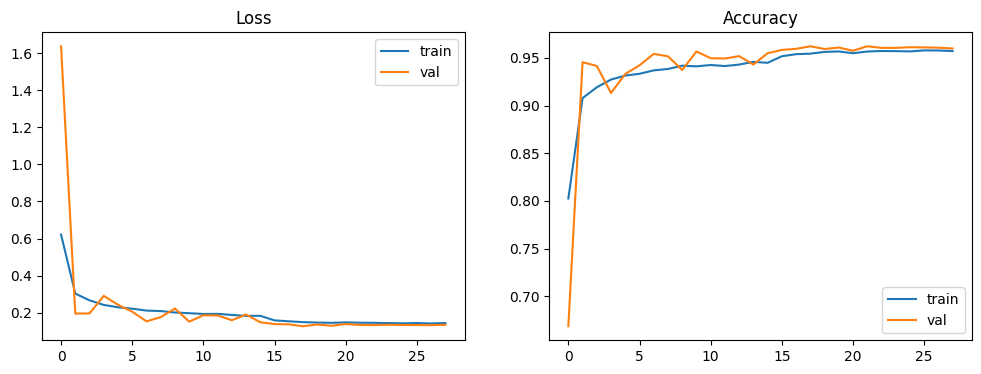

In [10]:
print("\n Plotting training curve")
plot_history(history)

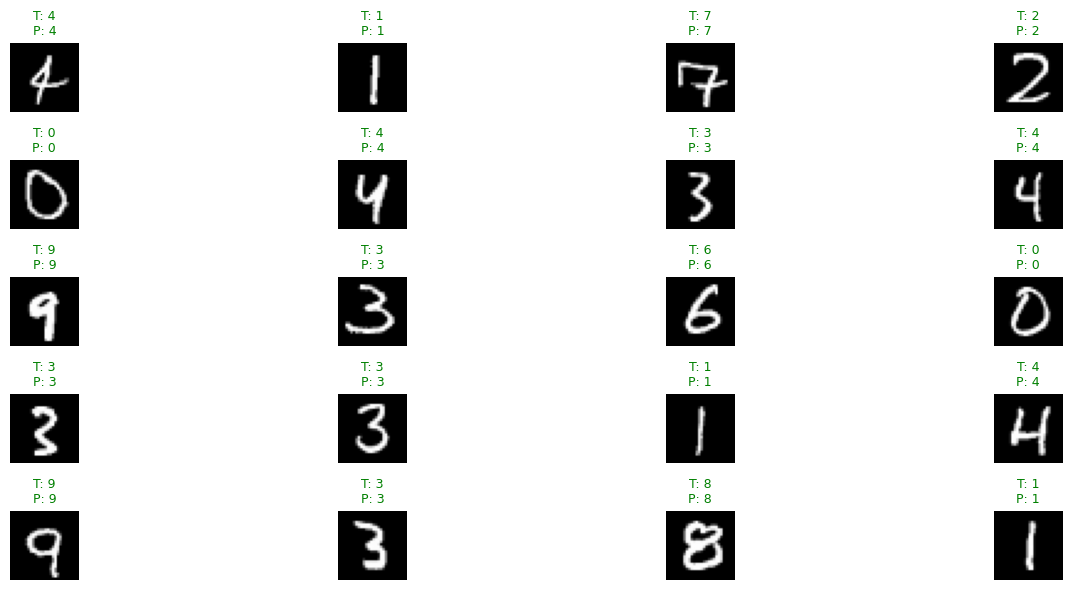

In [11]:
def predict_random_samples(model, dataset, class_names, num_samples=10):
    plt.figure(figsize=(15, 6))
    subset = dataset.unbatch().shuffle(buffer_size=1000, seed=None).take(num_samples)
    
    images = []
    true_labels = []
    for img, lbl in subset:
        images.append(img.numpy())
        true_labels.append(np.argmax(lbl.numpy()))
    images_arr = np.array(images)
    predictions = model.predict(images_arr, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)
    rows = int(np.ceil(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))
    
    if num_samples == 10:
        rows, cols = 2, 5
    for i in range(num_samples):
        plt.subplot(rows, cols, i + 1)
        img_display = (images_arr[i] * 255).astype("uint8").squeeze()
        
        plt.imshow(img_display, cmap='gray')
        
        is_correct = true_labels[i] == pred_labels[i]
        color = 'green' if is_correct else 'red'
        
        label_true = class_names[true_labels[i]]
        label_pred = class_names[pred_labels[i]]
        
        plt.title(f"T: {label_true}\nP: {label_pred}", color=color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

predict_random_samples(model, test_ds, CLASS_NAMES, num_samples=20)

# TFLite Export¶


In [12]:
%%time

def create_representative_dataset_generator(dataset, num_samples=20):
    def representative_dataset():
        for images, _ in dataset.take(num_samples).unbatch().batch(1):
            yield [tf.cast(images, tf.float32)]
    return representative_dataset

def export_quantized_tflite(keras_model, representative_dataset_gen, tflite_path):
    print(f"\n🛠️ Converting and quantizing to TFLite (INT8) in `{tflite_path}`...")

    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.int8

    tflite_model_quant = converter.convert()

    with open(tflite_path, "wb") as f:
        f.write(tflite_model_quant)

    keras_size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
    tflite_size_kb = len(tflite_model_quant) / 1024
    print(f"✅Export completed.  Keras: {keras_size_mb:.2f} MB |  TFLite: {tflite_size_kb:.1f} KB")



representative_data_gen = create_representative_dataset_generator(train_ds)
export_quantized_tflite(model, representative_data_gen, TFLITE_PATH)


🛠️ Converting and quantizing to TFLite (INT8) in `model_simple_int8.tflite`...
Saved artifact at '/tmp/tmp7qezbdke'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134004862488400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862489744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862490128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862491088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862490896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862490320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862488016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862487440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134004862489552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134

W0000 00:00:1771080755.004785      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1771080755.004818      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1771080755.015590      55 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


✅Export completed.  Keras: 0.10 MB |  TFLite: 11.5 KB
CPU times: user 3.24 s, sys: 216 ms, total: 3.46 s
Wall time: 2.73 s


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: INT8


In [13]:
import numpy as np
import tensorflow as tf

def evaluate_tflite_universal(tflite_path, dataset):
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero = input_details["quantization"]
    output_scale, output_zero = output_details["quantization"]

    correct = 0
    total = 0

    print(f"Testing TFLite Universal: {tflite_path}")

    for images, labels in dataset.unbatch().batch(1):
        img = images[0].numpy()
        lbl_raw = labels[0].numpy()

        if lbl_raw.size == 1:
            label = int(lbl_raw)
        else:
            label = np.argmax(lbl_raw)

        if input_details['dtype'] == np.uint8:
            img = img / input_scale + input_zero
            img = np.clip(img, 0, 255).astype(np.uint8)

        interpreter.set_tensor(input_details["index"], [img])
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]

        if output_details['dtype'] != np.float32:
             output = (output.astype(np.float32) - output_zero) * output_scale

        pred = np.argmax(output)

        if pred == label:
            correct += 1
        total += 1

    acc = correct / total if total > 0 else 0
    print(f"Accuracy TFLite: {acc:.4f}")
    return acc

In [14]:
evaluate_tflite_universal(TFLITE_PATH, test_ds)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Testing TFLite Universal: model_simple_int8.tflite
Accuracy TFLite: 0.9379


0.9379